In [1]:
%matplotlib inline

# What's this notebook about? 🤔

Last semester we covered how to detect what was in an image, today we'll be learning an approach which will tell you where an object is in an image!

This notebook takes a focus on YOLO architecture and utilizes it to detect Raccoons in an image in order to draw a bounding box around them.

<br>

**What we are doing today:**

- Images to Maths: We'll see how pictures of raccoons become 3D Tensors. 🦝

- The Error Metric: You will write the Loss Function. This is the most important part of machine learning - mathematically defining what a "bad guess" looks like.

- Training & Tuning: We'll use a GPU to teach the model to obsess over getting its boxes perfectly aligned.

<br>

*Note: We've provided an API (the 'backbone') to handle the heavy Python boilerplate. This allows you to focus purely on the Deep Learning Logic.*
The API can be found here: https://github.com/Coshea46/edi-ai-single-yolo-api


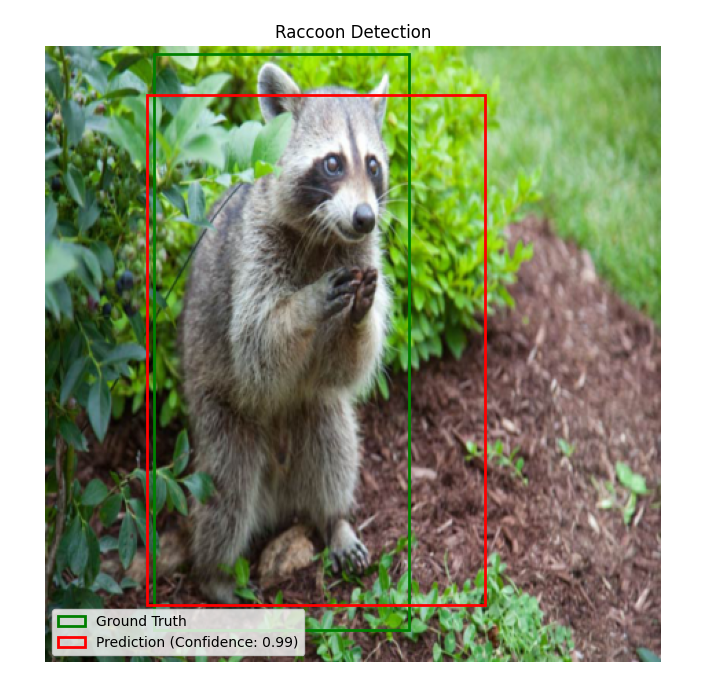





<hr>

# The Structure of this notebook 📖

**Main goal**

Complete all of the sections labeled "Task" sequentially

<br>

**What sort of things you'll need to do for tasks**

- Some tasks will be filling in the blanks for parameters
- Others may allow a more open approach, telling you what a function should output and letting you go about implementing it whichever way you like

<br>

**Tech stack used**

- [Pytorch](https://pytorch.org/)
- [Python](https://www.python.org/)
- [Pandas](https://pandas.pydata.org/)
- [yaml](https://yaml.org/)
- [scikit-learn](https://scikit-learn.org/stable/)

<hr>

# Task 1: Loading our data 💻

Machine learning is useless if we don't have any data. Our first task is to load the dataset into the notebook.

For this notebook we'll be using a dataset with pictures of raccoons. It can be found here: [Raccoon Dataset](https://www.kaggle.com/datasets/debasisdotcom/racoon-detection)

<br>

**Your Job:**

Import the dataset to this notebook using the 'add input' option in the right side bar

<br>


**Need help?**

Feel free to ask one of us coming around!


<hr>

# Task 2: Wrangling Our Data 🔧

*You can think of data wrangling as the process of getting our data in the format we want for our model*

Take a look at the dataset you've just imported (do this by going to the link above and scrolling down a bit).

Notice anything? Take a look at the columns in the dataset and think about what we need for our YOLO model


<br>

You should notice 2 key things:

- The center coordinates of the Raccoon are not explicity given
- The coordinates are not normalized


This brings us onto our first coding task

<br>

#### Your Task

1. Read the csv as a pandas dataframe
2. Create 3 new columns: normalized_center_x, normalized_center_y, normalized_box_width, normalized_box_height

<br>

**Think**

- *What will the midpoint of xmax and xmin give you?*
- *Can I go straight to normalized_center_x and normalized_center_y or is there maybe a step I have to take first?*
- *How do I normalize a coordinate?*
- *What type will Pandas parse the entries in my dataframe as?*
- *What type should each of my columns be?*
- *Do I need to consider na's?*


<br>

**Hints**

- We want our x coordinate to be on a scale of 0 to 1 how far am i along the image, likewise for the y coordinate
- The Pandas library provides some really nice tools for operating on columns of a dataframe in parallel, you may find the syntax similar to that of dictionaries in python
- Your dataset csv path should be "/kaggle/input/racoon-detection/train_labels_.csv"



<br>


**Helpful Resources**

- Gonna put my notes here
- Link to pandas docs here as well


In [2]:
import pandas as pd

data_csv_path = '/kaggle/input/racoon-detection/train_labels_.csv'
labels_df = pd.read_csv(data_csv_path)

# force pandas to convert the should be numerical columns to ints
labels_df['xmin'] = pd.to_numeric(labels_df['xmin'], errors='coerce')
labels_df['xmax'] = pd.to_numeric(labels_df['xmax'], errors='coerce')

labels_df['ymin'] = pd.to_numeric(labels_df['ymin'], errors='coerce')
labels_df['ymax'] = pd.to_numeric(labels_df['ymax'], errors='coerce')

labels_df['width'] = pd.to_numeric(labels_df['width'], errors='coerce')
labels_df['height'] = pd.to_numeric(labels_df['height'], errors='coerce')


# add new columns for normalized center point (x,y)
labels_df['normalized_center_x'] = (((labels_df['xmax'] + labels_df['xmin'])/2)/labels_df['width'])
labels_df['normalized_center_y'] = (((labels_df['ymax'] + labels_df['ymin'])/2)/labels_df['height'])

# add new columns for normalized width and height of the bounding box
labels_df['normalized_box_width'] = (labels_df['xmax'] - labels_df['xmin'])/labels_df['width']
labels_df['normalized_box_height'] = (labels_df['ymax'] - labels_df['ymin'])/labels_df['height']

# Drop any rows that failed the numeric conversion or normalization
labels_df = labels_df.dropna(subset=['normalized_center_x', 'normalized_center_y', 
                                     'normalized_box_width', 'normalized_box_height'])


<hr>

# Loading our hyperparameters ⚙️

We'll use a file format called YAML to store our hyperparameters, you'll find this already in your input directory.

<br>

**Why YAML?** 

In machine learning, we often need to tweak dozens of variables (learning rate, weights, batch size). Hard-coding these inside your Python scripts is bad practice because:

- Decoupling: You can change how the model trains without ever touching the actual code.

- Reproducibility: You can save the YAML file alongside your trained model weights so you know exactly which settings produced that specific result.

- Readability: YAML is designed to be "human-readable," making it much easier to scan than a wall of nested JSON.

<br>

**What does a YAML file look like? 📜**

YAML relies on indentation to represent data

The one in this notebook looks like:

In [3]:
!cat /kaggle/input/config-yaml/config.yaml

training:
  batch_size: 16
  epochs: 50
  test_data_size: 0.2

loss_weights:
  coord_loss_weight: 5.0
  confidence_loss_weight: 0.5

data:
  img_size: 448
  parquet_path: "./cleaned_labels.parquet"

optimizer_params:
  learning_rate: 0.0001
  weight_decay: 0.00005

evaluation:
  iou_threshold: 0.25
  confidence_threshold: 0.5

### Don't worry about the implementation of how we read the file but if you're interested it's here:

In [4]:
import yaml

# parse the yaml file
def load_config(config_path="/kaggle/input/config-yaml/config.yaml"):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config

# you can now access model configurations like a dictionary
model_configurations = load_config()

<hr>

# Task 4: Turn our image data into tensors 🔢

**Important:** Artificial Neural Networks can only operate on numbers. If we were to pass e.g. a jpeg straight our model, it wouldnt make any sense as it doesn't fit the input structure.

<br>

We need to design a transformation function that:

1. Takes in an image
2. Resizes it (so that all of our input images are the same size)
3. Converts it to a tensor
4. Normalizes the tensor just made

<br>

**Why are we resizing the image 📏**

If you look through the dataset you'll see that the images are all of varying heights and widths. 
The reason this is a problem is because the input layer to our model will expect all of the tensors it receives to be the same size.

In PyTorch, if you try to give a neural network layer a tensor of a different shape than the one it expects, the program will crash.

<br>


**Why normalize the tensor**

RGB values range from 0 to 255, this is a massive range in the context of machine learning.

If we have big numerical gaps between features in our input vector, we risk the multiplications in the network blowing up for some features and completely drowning out other features. We don't want those smaller features getting drowned out since RGB is just a scale of pixel intesity, not necessarily how important those pixels are.


<br>

### Your job

1. Inspect the config.yaml file and check what image size our model will take in as input
2. Insert this value into the code in the correct place


<br>
**You may find these links usefull**

- Include link to pytorch tensor docs here
- include link to own tensor notes here

In [5]:
from torchvision import transforms

def get_transforms(img_size=448): # Set 448 as the default
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

<hr>

# Task 5: Split your datasets into training and test data 📂

**What about the evaluation data 🚨???**

Whenever we're doing machine learning, we usually want to split our dataset into 3 subsets:

- Training - Used for teaching the model 
- **Evaluation** - Used for seeing how well the model is doing *while* it's training
- Testing - Used for seeing how good a model we have after all training is complete

Evaluation data is useful for seeing if our model is learning the relationships in the data properly, instead of just memorizing the training data. If we can detect that it's not learning properly we can stop the training loop early and tweak the components in the training loop - this saves us time that would've been wasted in letting the loop complete.

*However,* with the Raccoon dataset we only have around 200 training examples. This is not enough data to split 3 ways.

It's not ideal but in this case we'll not have any data for 2 main reasons:

- It means we can have more training and testing data
- Since we don't have many training examples, the model doesn't take that long to train anyway so we're not really wasting much time if we don't stop early when we maybe should.

<br>

#### Your Job

Fill in the blanks below 

<br>

***VERY IMPORTANT❗***

The variable you use to name your testing dataframe must be: test_df

In [6]:
import sys
import importlib

# Delete the old module from Python's memory
if 'dataset_backbone' in sys.modules:
    del sys.modules['dataset_backbone']
    
!wget https://raw.githubusercontent.com/Coshea46/edi-ai-single-yolo-api/refs/heads/main/dataset_backbone.py
from dataset_backbone import RaccoonDataset
from sklearn.model_selection import train_test_split

# first as pandas dataframes
train_df, test_df = train_test_split(labels_df, test_size=model_configurations['training']['test_data_size'], random_state=42)

# We use the transormation function we defined earlier here!
resize_normalize_transformation = get_transforms(img_size=model_configurations['data']['img_size'])

training_dataset = RaccoonDataset(train_df, resize_normalize_transformation)
testing_dataset = RaccoonDataset(test_df, resize_normalize_transformation)


--2026-01-26 17:27:34--  https://raw.githubusercontent.com/Coshea46/edi-ai-single-yolo-api/refs/heads/main/dataset_backbone.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1050 (1.0K) [text/plain]
Saving to: ‘dataset_backbone.py’

dataset_backbone.py 100%[===================>]   1.03K  --.-KB/s    in 0s      

2026-01-26 17:27:34 (62.1 MB/s) - ‘dataset_backbone.py’ saved [1050/1050]



<hr>

# Task 6: Build the head of the model 🧠

In Deep Learning, the Head is the final section of a neural network responsible for turning the relationships learned by our model, into the output format we want.

The rest of our model is just a convolutional neural network but you don't need to worry about implementing that for this workshop - *If we you want to learn more about implementing convolutional neural networks, see our workshop from last semester here 🔗: (https://github.com/EdinburghAI/workshops/blob/main/TheoreticalWorkshops/Sem1Workshop3/CNNs-Solved.ipynb)*


## For this notebook

You need to design the head of the model so that it uses linear layers to turn the shape of our output into the one we want for single object YOLO:

`[confidence, x_center_normalized, y_center_normalized, norm_box_width, norm_box_height]`


<br>

**What you need to know for this task**

- Your head will take in a **flat** tensor of size = 50176
- Your head should output a tensor of the same shape as the one given above (this one: `[confidence, x_center_normalized,etc.]`

<br>


**Need help?**

Here's some information how to use the `nn.Linear` function in PyTorch

(link to own documentation on nn.Linear here)


In [7]:
import torch.nn as nn   # rename the nn module for easier to read code
import pandas as pd


!wget https://raw.githubusercontent.com/Coshea46/edi-ai-single-yolo-api/refs/heads/main/model_backbone.py

from model_backbone import RaccoonDetectionModel

class RaccoonDetectionModel(RaccoonDetectionModel):
    def __init__(self):
        super().__init__() # Initializes the backbone
        
        # TASK: Build the 'Brain' of the model
        # Input size: 50,176 -> Output size: 5
        self.head = nn.Sequential(
            nn.Linear(50176, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 5),
            nn.Sigmoid()
        )

# Now 'model' is an instance of RaccoonDetectionModel
model = RaccoonDetectionModel()

--2026-01-26 17:27:35--  https://raw.githubusercontent.com/Coshea46/edi-ai-single-yolo-api/refs/heads/main/model_backbone.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3282 (3.2K) [text/plain]
Saving to: ‘model_backbone.py’

model_backbone.py   100%[===================>]   3.21K  --.-KB/s    in 0s      

2026-01-26 17:27:35 (58.4 MB/s) - ‘model_backbone.py’ saved [3282/3282]



<hr>

# Task 7: Define your loss function 📉

*Recall the loss function we talked about in the workshop*
(https://github.com/Coshea46/edi-ai-single-yolo-api/blob/main/single-obj-yolo-presentation.pptx)

We want our loss function to be able to penalize the model (tell it to update its weights as the current ones aren't correct) if it gets either of these two things wrong:

- The confidence score - is the raccoon actually in the image?
- The center coordinate of the raccoon in the image



***Further notes on the loss function here***

(include link to notes in repo here)


***Notes on the PyTorch syntax***

(include link to PyTorch notes on e.g. the `[:,0]` syntax here)

<br>

## What is criterion 🤔

At the bottom of the code chunk you'll see we're initializing a variable called criterion (don't worry you don't have to implement this code yourself, it's already done for you).

criterion is essentially the object we'll use in our training loop for calculating the loss for a given batch in our training data - it's basically just a container for our loss function, making our training loop syntax simpler.

<br>

**Why the name?**

The literal definition of criterion in English is: "a standard or a rule by which something is judged".

In Deep Learning, that standard is our Loss.


In [8]:
import torch
import torch.nn as nn
!rm loss_backbone.py
import sys

# Force Python to "forget" the old module from its internal registry
if 'loss_backbone' in sys.modules:
    del sys.modules['loss_backbone']
    
!wget https://raw.githubusercontent.com/Coshea46/edi-ai-single-yolo-api/refs/heads/main/loss_backbone.py
from loss_backbone import loss_backbone


# takes in the predictions and targets tensors
def yolo_loss_function(predictions, targets, confidence_weight, coord_weight, mse):
    # first compute the confidence loss - we can just use weighted mse for this
        confidence_loss = mse(predictions[:,0],targets[:,0])

        # now we want to weight the confidence loss by out parameter in the yaml file
        confidence_loss = confidence_loss * confidence_weight


        # now we want the equation for the wrong box loss
        # we'll start with the loss from predicting the center of the box
        x_center_loss = (targets[:,1] - predictions[:,1])**2
        y_center_loss = (targets[:,2] - predictions[:,2])**2

        center_loss = x_center_loss + y_center_loss


        # Use clamp to prevent sqrt(0) or negative numbers from causing NaN.
        pred_w_sqrt = torch.sqrt(torch.clamp(predictions[:, 3], min=1e-6))
        pred_h_sqrt = torch.sqrt(torch.clamp(predictions[:, 4], min=1e-6))
        target_w_sqrt = torch.sqrt(targets[:, 3])
        target_h_sqrt = torch.sqrt(targets[:, 4])

        box_loss = (pred_w_sqrt - target_w_sqrt) ** 2 + (pred_h_sqrt - target_h_sqrt) ** 2


        coord_loss = box_loss + center_loss

        # need to make it so that we only punish wrong box drawing when target confidence is 1
        # element-wise multiplication
        coord_loss = coord_loss * targets[:,0]

        # scale coord loss by hyperparameter to make model obsess over boxes
        coord_loss = coord_loss * coord_weight

        # Now we sum the 2 errors to get the total loss
        # note: at this point we have a vector of losses for each datapoint in the batch, not a single value yet
        total_loss_vector = coord_loss + confidence_loss

        return torch.mean(total_loss_vector)




# instantiate the loss function object
criterion = loss_backbone(confidence_weight=model_configurations['loss_weights']['confidence_loss_weight'],
                        coord_weight=model_configurations['loss_weights']['coord_loss_weight'], loss_logic_fn=yolo_loss_function)

        

rm: cannot remove 'loss_backbone.py': No such file or directory
--2026-01-26 17:27:36--  https://raw.githubusercontent.com/Coshea46/edi-ai-single-yolo-api/refs/heads/main/loss_backbone.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 619 [text/plain]
Saving to: ‘loss_backbone.py’

loss_backbone.py    100%[===================>]     619  --.-KB/s    in 0s      

2026-01-26 17:27:36 (32.5 MB/s) - ‘loss_backbone.py’ saved [619/619]



<hr>

# Task 8: Choose your Training Strategy 🛠️

When we're training a neural network we need a rule for how we update our weights.

<br>

**Is our loss function not the rule?**

Not quite

We use the loss function as part of the equation for calculating our weight update. It just tells us whether the weights in the given layer should go up or down and vaguely by how much.

<br>

**Where optimizers come into this**

We can use what's called an optimizer for defining and applying our weight update rule in our training loop.

A couple of common options are:

- Stochastic Gradient Descent (we saw this last semester!) -
- ADAM


<br>

For this workshop we'll use Adam as our optimizer because it’s simple to use and works well in most situations:

- **It automatically adjusts itself** - 
Instead of using the same step size everywhere, Adam changes how big each step is for different parts of the model. Think of it like cruise control that slows down when the road gets twisty and speeds up when things are clear.

- **It remembers past progress** - 
Adam keeps track of which direction things were improving before and continues moving that way. Like a ball rolling downhill, it doesn’t stop at every small bump, it keeps going toward a better solution.

- **It’s very forgiving** - 
Adam usually works well even if you don’t pick the perfect settings. For beginners, this is great because you can get good results without a lot of trial and error.


<br>

## Your Task: What you've got to do

*Have a look at the ADAM documentation here: https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html*

Decide what order the learning_rate and weight_decay parameters should go into the Adam constructor function in the code chunk below.


<br>


***Want to learn more about optimzers?***

There's some notes on ADAM and Stochastic Gradient Descent here:

(include link to own notes on github here)



In [9]:
import torch.optim as optim
# instantiate optimizer
params = model.parameters()

learning_rate = model_configurations['optimizer_params']['learning_rate']
weight_decay = model_configurations['optimizer_params']['weight_decay']

optimizer = optim.Adam(
    params, 
    lr=learning_rate,
    weight_decay=weight_decay
)



<hr>

# Task 9: Train your model ⚡

Now it's time for our machine to actually learn 🎉

<br>

We train our models by looping over our training dataset - we call the number of times we loop over the dataset the number of "epochs". 

For each iteration in this loop we need to do 3 things:

- Split the dataset into chunks (known as batching)
- Loop over each chunk (aka batch) we've just made (we use a nested loop for this of course)
- Track the loss accumulated over those chunks (aka batches)

<br>

**The work within the nested loop (batch loop)**

For each batch iteration we put the entire batch through the model in paralell (this is why gpu's are so important in deep learning!).

The key work we do on the batch is:

1. Get the output from the model for all of the data points in the batch
2. Compute the loss for the batch
3. Use backpropagation to propagate the loss through the model (to find out how much each layer in the model is to blame for the error)
4. Call the optimizer to update all of the weights for us accordingly


<br>

### Your Mission (if you choose to accept)

1. Pass the batch through the model
2. Compute the loss for the batch
3. Call the torch function for back propagation
4. Call the the optimizer to update the weights



<br>

**Some useful PyTorch guidance**

(include link to own notes here on backwards etc.)



In [10]:
from torch.utils.data import DataLoader
# Convert datasets to dataloader objects
training_dataset_loader = DataLoader(training_dataset, batch_size=model_configurations['training']['batch_size'], shuffle=True)
testing_dataset_loader = DataLoader(testing_dataset, batch_size=model_configurations['training']['batch_size'], shuffle=True)


# first move the model to the gpu to allow it to train faster
# use the gpu if it supports cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# finally time for the training loop
num_epochs = model_configurations['training']['epochs']

for epoch in range(num_epochs):
    
     # Track performance for this epoch
    epoch_loss = 0.0
    for inputs, targets in training_dataset_loader:

        # move training tensors to gpu
        inputs = inputs.to(device)
        targets = targets.to(device)

        # clear gradients saved from last batch
        optimizer.zero_grad()

        # inputs variable is the currents batch of tensors
        outputs = model(inputs)
        
        loss = criterion(outputs, targets)

        # backpropagation
        loss.backward()

        # update weights
        optimizer.step()

        # update the running total for loss of the epoch
        epoch_loss += loss.item()


    # End of Epoch Summary
    avg_loss = epoch_loss / len(training_dataset_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}")



Epoch [1/50], Average Loss: 1.8149
Epoch [2/50], Average Loss: 1.9309
Epoch [3/50], Average Loss: 1.6641
Epoch [4/50], Average Loss: 1.5855
Epoch [5/50], Average Loss: 1.3181
Epoch [6/50], Average Loss: 1.1608
Epoch [7/50], Average Loss: 0.9444
Epoch [8/50], Average Loss: 0.9099
Epoch [9/50], Average Loss: 0.8239
Epoch [10/50], Average Loss: 0.7478
Epoch [11/50], Average Loss: 0.7492
Epoch [12/50], Average Loss: 0.5314
Epoch [13/50], Average Loss: 0.3874
Epoch [14/50], Average Loss: 0.3026
Epoch [15/50], Average Loss: 0.2942
Epoch [16/50], Average Loss: 0.2781
Epoch [17/50], Average Loss: 0.2653
Epoch [18/50], Average Loss: 0.2538
Epoch [19/50], Average Loss: 0.2589
Epoch [20/50], Average Loss: 0.2462
Epoch [21/50], Average Loss: 0.2534
Epoch [22/50], Average Loss: 0.2398
Epoch [23/50], Average Loss: 0.2195
Epoch [24/50], Average Loss: 0.2174
Epoch [25/50], Average Loss: 0.2194
Epoch [26/50], Average Loss: 0.1915
Epoch [27/50], Average Loss: 0.2165
Epoch [28/50], Average Loss: 0.2194
E

<hr>

# Task 10: Evaluate your model 🧪

Let's see if our model is any good 🔎

<br>

One very common evaluation metric in machine learning is to get the ratio of correct predictions to total predictions:

$$\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$$

But how do we define what a "correct prediction" actually is in Object Detection? It isn't just a Yes/No answer, we have to look at how sure the model was and where it put the box.

<br>

**Intersection over Union**

As we said in the workshop, one way of seeing if our model's prediction is "close enough" to what it should be is by using Intersection over Union (IoU).

Intersection over union is exactly as it says: we get the amount of area that both the truth box and our predicted box cover, and divide that by the total area covered by both the boxes.

$$\text{IoU} = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$



We can then define a threshold ourselves (e.g., 0.3) for saying what minimum ratio value is acceptable.

<br>

**What does "good" look like for a YOLO model?**

In the code below, we are tracking three specific results to see how the model performed:

* **Hits (True Positives):** The model was confident AND the box was in the right spot (High IoU).
* **Gaps (False Positives):** The model was confident, but it put the box in the wrong place.
* **Misses (False Negatives):** The model didn't find the raccoon, or it wasn't confident enough it was there.



We combine these into a Precision score (when it speaks up, is it right?) and a Recall score (how many of the total raccoons did it actually find?).

<br>

**In our model's case:**

Sadly, due to not having much data, our model has a lot of wrong predictions. You will likely see a low F1 Score, which is the balanced grade between Precision and Recall.

<br>

***Think: How could we improve our model in future? 🤔***

My advice:

- **More data:** Our dataset is really really small, ideally look for about 1000 examples.
- **Tweak the hyperparameters:** Tweak the weights and see what happens (you'll see this in the extension!).
- **Smart Resizing:** Is there a better transformation we could use on our images instead of squishing them all?

<br>

**Need any help?**

- See intersection over union in detail here: [link to own notes here]

- See evaluation metrics in more detail here: [link to own notes here]

In [11]:
!wget https://raw.githubusercontent.com/Coshea46/edi-ai-single-yolo-api/refs/heads/main/intersection_over_union.py
from intersection_over_union import iou_batch


total_val_loss = 0.0

model.eval()

# init metrics
total_close_enough = 0  # correct confidence and a close enough box
total_wrong_confidence = 0  # wrong confidence, dont care about box in this case
total_bad_box = 0  # correct confidence but bad box

tp = 0
tn = 0
fp = 0
fn = 0

total_gt = 0

conf_threshold = model_configurations['evaluation']['confidence_threshold']
iou_threshold = model_configurations['evaluation']['iou_threshold']

with torch.no_grad():
    for inputs, targets in testing_dataset_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)

        # 1. Update total ground truths (for Recall/FN)
        total_gt += targets.size(0)

        # 2. Get IoUs for the whole batch at once

        batch_ious = iou_batch(outputs, targets) 

        # 3. Step-by-step logic for your workshop categories:
        for i in range(len(outputs)):
            conf = outputs[i, 0] # Assuming index 0 is confidence
            iou = batch_ious[i]

            if conf >= conf_threshold:
                if iou >= iou_threshold:
                    total_close_enough += 1 # This is a True Positive
                    tp += 1
                else:
                    total_bad_box += 1      # This is a FP (Confident but wrong)
                    fp += 1
            else:
                total_wrong_confidence += 1 # Model was too "shy"
                # This box is ignored. If it was the only prediction for 
                # a target, it will naturally become a False Negative.

# 4. Final calculation after the loop
fn = total_gt - tp

precision = tp / (tp + fp + 1e-7)

# Recall: "Of all the objects that actually exist, how many did we find?"
recall = tp / (total_gt + 1e-7)

# F1 Score: The 'Balanced Grade'
f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)

print("-" * 30)
print(f"WORKSHOP EVALUATION RESULTS")
print("-" * 30)
print(f"Total Objects in Dataset: {total_gt}")
print(f"True Positives (Hits):   {tp}")
print(f"False Positives (Gaps):  {fp}")
print(f"False Negatives (Miss):  {fn}")
print("-" * 30)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1_score:.4f}")
print("-" * 30)

--2026-01-26 17:29:17--  https://raw.githubusercontent.com/Coshea46/edi-ai-single-yolo-api/refs/heads/main/intersection_over_union.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1737 (1.7K) [text/plain]
Saving to: ‘intersection_over_union.py’

intersection_over_u 100%[===================>]   1.70K  --.-KB/s    in 0s      

2026-01-26 17:29:17 (29.1 MB/s) - ‘intersection_over_union.py’ saved [1737/1737]

------------------------------
WORKSHOP EVALUATION RESULTS
------------------------------
Total Objects in Dataset: 35
True Positives (Hits):   23
False Positives (Gaps):  12
False Negatives (Miss):  12
------------------------------
Precision: 0.6571
Recall:    0.6571
F1 Score:  0.6571
------------------------------


<hr>

# Lets see the results! 👀

**The moment of truth!**

Run the code chunk below as many times as you like to see the **predicted boxes** sketched onto the images. 

* **Red Box:** The box our model predicted
* **Green Box** The box that the label defined in the dataset
* **Confidence Score:** How sure the model is that it found a raccoon.


<br>

### Key point

This is done for you in the API we've provided, but you should be wary of the fact that our model outputs normalized coordinates - means that whenever you're using software to draw the boxes defined by the model, you need to turn the coordinates output by the model into raw, un-normalized, coordinates.



<br>

### Do you see any interesting examples? 🤔

We only trained our model to predict one raccoon per image but there's a couple of images in our dataset that actually have 2 raccoons in them.

*How did our model handle this?*


--2026-01-26 17:29:18--  https://raw.githubusercontent.com/Coshea46/edi-ai-single-yolo-api/refs/heads/main/results_viewer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1616 (1.6K) [text/plain]
Saving to: ‘results_viewer.py’

results_viewer.py   100%[===================>]   1.58K  --.-KB/s    in 0s      

2026-01-26 17:29:18 (31.1 MB/s) - ‘results_viewer.py’ saved [1616/1616]



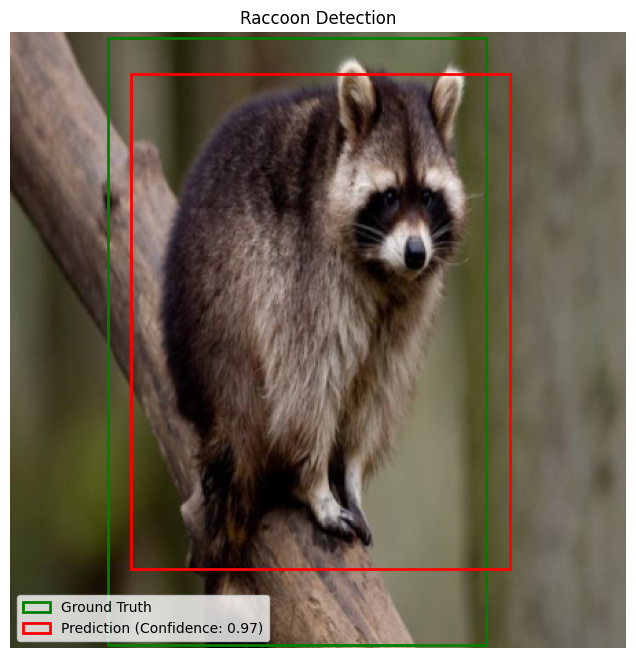

In [12]:
!wget https://raw.githubusercontent.com/Coshea46/edi-ai-single-yolo-api/refs/heads/main/results_viewer.py
from results_viewer import display_results


# We pass in the model we trained and the testing data
display_results(model, testing_dataset_loader, device)

<hr>

# Saving the state of the model 💾

We can save the weights of our model for later so that if you can e.g.

- Adjust the model and train it again (you could tweak the learning rate for example)
- Run it again for some application your building

<br>

*This code should save the weights of your model to the /kaggle/working directory*

In [13]:
torch.save(model.state_dict(), 'raccoon_model.pth')

<hr>

# 🚀 Extension: Tune the model's hyperparameters ⚙️

*Don't worry if you don't get to this part!*

In the yaml file you'll see a few key hyperparameters you can tune the model with:

- *learning_rate:* controls how aggressive the weight updates we make in our training loop are
- *iou_threshold:* Determines how strict we are in clasifying if our box is close enough to what it should be
- *weight_decay:* Acts as a penalty on large weights. It prevents the model from becoming too reliant on any single pixel or feature, which helps stop overfitting (where the model memorizes the training data instead of learning to generalize).
- *epochs:* The total number of times the model loops over the dataset during training

<br>

**Your Task**

1. Make your own config.yaml file locally on your machine and change a couple of the parameters.

2. Then delete the current config.yaml file in the notebook and upload your own.

<br>

*What sort of effect does your choice of hyperparameters have on the model?*